# USD/CHF Forex Forecasting - 3 Model Regression

KNN Regressor | SVR | XGBoost Regressor

Notebook ini berisi pipeline lengkap: spesifikasi data, preprocessing, training 3 model, evaluasi regression & classification, PCA, dan uji coba parameter tuning.

Dataset: USD/CHF 1-minute OHLCV dari histdata.com
Periode: 2025-01-01 s/d 2026-05-29
Total Baris: 522,862

## 1. Spesifikasi Data

### 1.1 Deskripsi
Dataset forex USD/CHF 1-min OHLCV dari histdata.com.

Atribut: datetime (index), open, high, low, close (target), volume (always 0).
Karakteristik: Non-stationary, bullish 2025, bearish early 2026.

In [1]:
import sys, os, warnings, time, pickle
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, silhouette_score)
import xgboost as xgb

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
os.makedirs('outputs/plots', exist_ok=True)
os.makedirs('outputs/models', exist_ok=True)
print("All imports OK")

All imports OK


In [2]:
# 1.2 Load Dataset
df = pd.read_csv("data/processed/USDCHF_1min_3y.csv")
df["datetime"] = pd.to_datetime(df["datetime"])
df.set_index("datetime", inplace=True)
df.sort_index(inplace=True)
df.drop(columns=["volume"], inplace=True)
print(f"Shape: {df.shape}")
print(f"Range: {df.index.min()} -> {df.index.max()}")
print(f"Nulls: {df.isnull().sum().sum()}")
display(df.head(10))
display(df.describe().T)

Shape: (522862, 4)
Range: 2025-01-01 17:04:00 -> 2026-05-29 16:58:00
Nulls: 0


,open,high,low,close
datetime,,,,
2025-01-01 17:04:00,0.90517,0.90546,0.90517,0.90517
2025-01-01 17:05:00,0.90517,0.90521,0.90517,0.90521
2025-01-01 17:06:00,0.90521,0.90521,0.90521,0.90521
2025-01-01 17:07:00,0.90521,0.90524,0.90512,0.90513
2025-01-01 17:08:00,0.90513,0.90513,0.90513,0.90513
2025-01-01 17:09:00,0.90515,0.90515,0.90515,0.90515
2025-01-01 17:10:00,0.90515,0.90515,0.90515,0.90515
2025-01-01 17:11:00,0.90515,0.90517,0.90515,0.90517
2025-01-01 17:12:00,0.90517,0.90517,0.90517,0.90517


,count,mean,std,min,25%,50%,75%,max
open,522862.0,0.817100,0.041326,0.76057,0.79149,0.80127,0.82406,0.91997
high,522862.0,0.817163,0.041329,0.76074,0.79154,0.80132,0.82415,0.92011
low,522862.0,0.817035,0.041322,0.76040,0.79144,0.80121,0.82395,0.91985
close,522862.0,0.817099,0.041326,0.76056,0.79149,0.80126,0.82405,0.91997


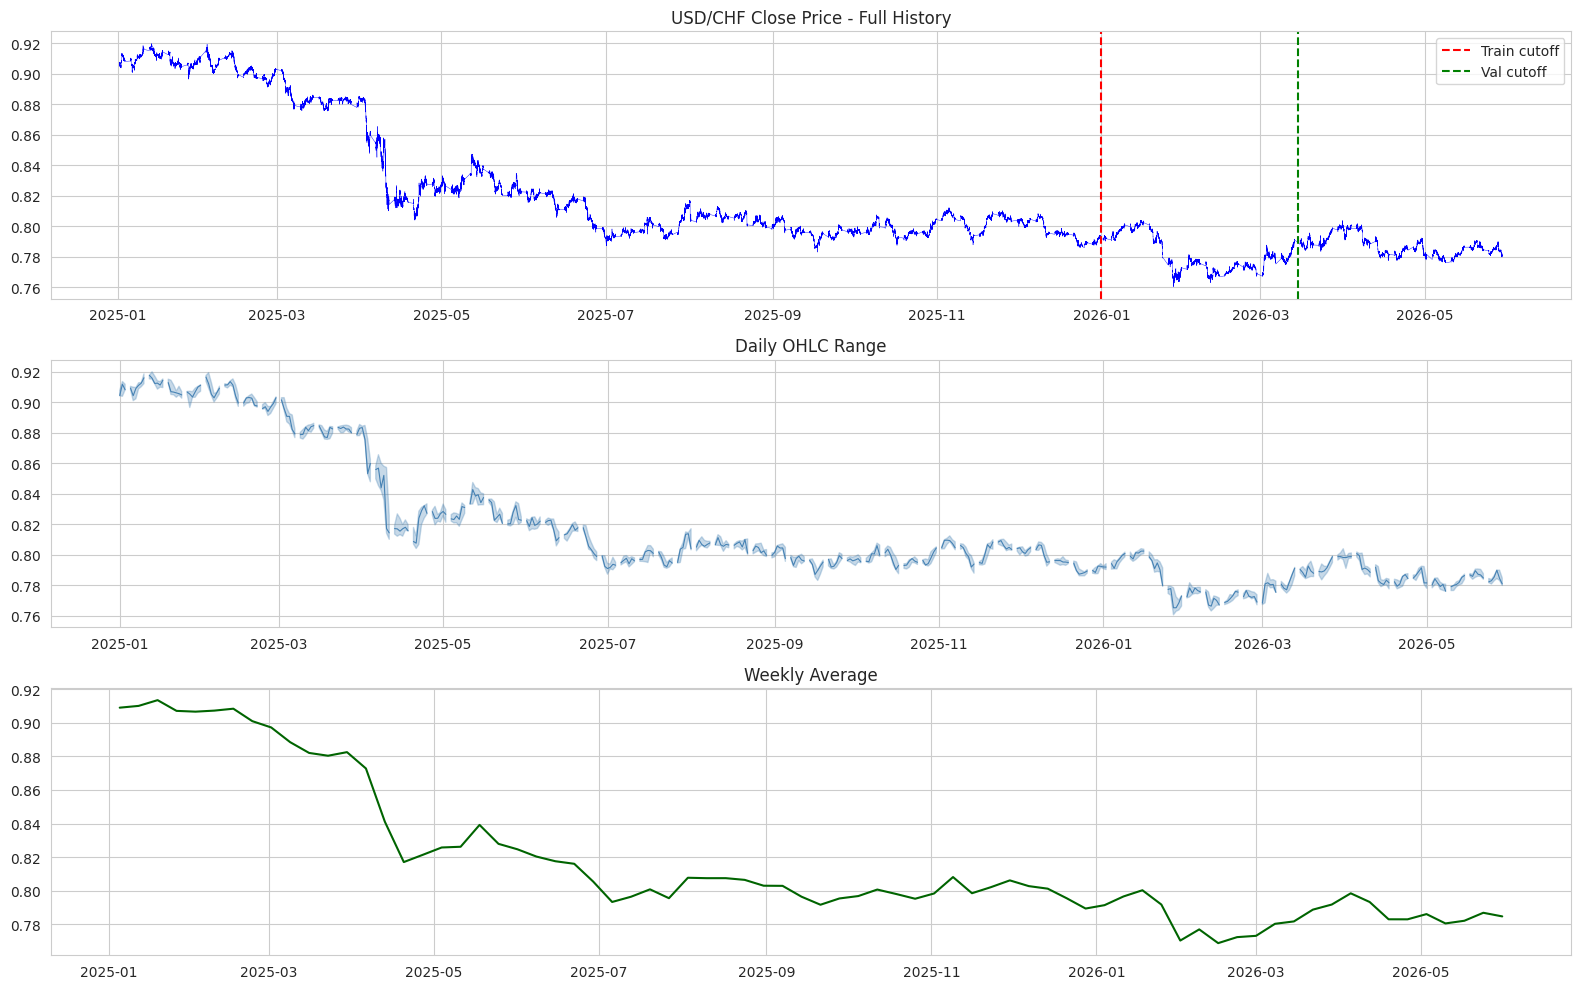

Data overview saved


In [3]:
# 1.3 Visualisasi Harga
fig, axes = plt.subplots(3, 1, figsize=(16, 10))
axes[0].plot(df.index, df["close"], color="blue", linewidth=0.3)
axes[0].axvline(x=pd.Timestamp("2026-01-01"), color="red", linestyle="--", label="Train cutoff")
axes[0].axvline(x=pd.Timestamp("2026-03-15"), color="green", linestyle="--", label="Val cutoff")
axes[0].set_title("USD/CHF Close Price - Full History"); axes[0].legend()

daily = df["close"].resample("1D").ohlc()
axes[1].fill_between(daily.index, daily["low"], daily["high"], alpha=0.3, color="steelblue")
axes[1].plot(daily.index, daily["close"], color="steelblue", linewidth=0.8)
axes[1].set_title("Daily OHLC Range")

weekly = df["close"].resample("1W").mean()
axes[2].plot(weekly.index, weekly, color="darkgreen", linewidth=1.5)
axes[2].set_title("Weekly Average")
plt.tight_layout(); plt.savefig("outputs/plots/data_overview.png", dpi=150); plt.show()
print("Data overview saved")

## 2. Preprocessing

### 2.1 Handle Missing Values

In [4]:
for col in ["open","high","low","close"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
before = len(df); df.dropna(inplace=True); after = len(df)
print(f"Dropped {before-after} NaN rows. Remaining: {after:,}. Nulls: {df.isnull().sum().sum()}")

Dropped 0 NaN rows. Remaining: 522,862. Nulls: 0


### 2.2 Feature Engineering (42 features)

In [5]:
# Lag features
for lag in [1,2,3,5,10,15,30,60]:
    df[f"close_lag_{lag}"] = df["close"].shift(lag)

# Rolling features
for window in [5,10,30,60]:
    roll = df["close"].rolling(window=window)
    for stat in ["mean","std","min","max"]:
        df[f"close_roll_{stat}_{window}"] = getattr(roll, stat)()

# Price-derived
df["log_return"] = np.log(df["close"] / df["close"].shift(1))
df["pct_change"] = df["close"].pct_change()
df["hl_spread"] = df["high"] - df["low"]
df["oc_range"] = df["close"] - df["open"]
df["ohlc_mean"] = (df[["open","high","low","close"]]).mean(axis=1)

# RSI
delta = df["close"].diff()
gain = delta.where(delta > 0, 0.0)
loss = (-delta).where(delta < 0, 0.0)
df["rsi_14"] = 100 - (100/(1 + gain.rolling(14,min_periods=14).mean() / loss.rolling(14,min_periods=14).mean()))

# Bollinger Bands
ma20 = df["close"].rolling(20).mean(); std20 = df["close"].rolling(20).std()
df["bb_upper_20"] = ma20 + 2*std20; df["bb_lower_20"] = ma20 - 2*std20
df["bb_width_20"] = df["bb_upper_20"] - df["bb_lower_20"]
df["bb_position_20"] = (df["close"] - df["bb_lower_20"]) / df["bb_width_20"]

# MACD
ema12 = df["close"].ewm(span=12,adjust=False).mean()
ema26 = df["close"].ewm(span=26,adjust=False).mean()
df["macd"] = ema12 - ema26
df["macd_signal"] = df["macd"].ewm(span=9,adjust=False).mean()
df["macd_hist"] = df["macd"] - df["macd_signal"]

# Time features
df["hour"] = df.index.hour; df["dayofweek"] = df.index.dayofweek
df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24); df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)
df["dow_sin"] = np.sin(2*np.pi*df["dayofweek"]/7); df["dow_cos"] = np.cos(2*np.pi*df["dayofweek"]/7)

# Target
df["target"] = df["close"].shift(-1)
df.dropna(inplace=True)
print(f"Feature-engineered shape: {df.shape}")

selected_features = [c for c in df.columns if c not in ["open","high","low","close","target","hour","dayofweek"]]
print(f"Features: {len(selected_features)} selected")
display(df[["close","target"] + selected_features[:5]].head())

Feature-engineered shape: (522790, 48)
Features: 41 selected


,close,target,close_lag_1,close_lag_2,close_lag_3,close_lag_5,close_lag_10
datetime,,,,,,,
2025-01-01 18:05:00,0.90708,0.90712,0.90702,0.90719,0.90708,0.90667,0.90566
2025-01-01 18:06:00,0.90712,0.90722,0.90708,0.90702,0.90719,0.90697,0.90566
2025-01-01 18:07:00,0.90722,0.90726,0.90712,0.90708,0.90702,0.90708,0.90613
2025-01-01 18:08:00,0.90726,0.90740,0.90722,0.90712,0.90708,0.90719,0.90613
2025-01-01 18:09:00,0.90740,0.90740,0.90726,0.90722,0.90712,0.90702,0.90613


## 2.3 Feature Selection (Correlation Analysis)

**Catatan Penting:** Fitur `close_lag_*` adalah harga yang digeser - sehingga antar lag saling berkorelasi ~1.0.
Ini NORMAL untuk data time-series. Oleh karena itu, heatmap di bawah memilih fitur **diverse**
dari berbagai kategori (lag, rolling, indicator) agar lebih informatif.

Top 10 by correlation with target:
ohlc_mean             0.999995
close_lag_1           0.999991
close_roll_mean_5     0.999991
close_roll_max_5      0.999988
close_roll_min_5      0.999988
close_lag_2           0.999987
close_roll_mean_10    0.999985
close_lag_3           0.999983
close_roll_min_10     0.999979
close_roll_max_10     0.999979
Name: target, dtype: float64

Diverse features selected for heatmap (8):
['close_lag_1', 'close_roll_mean_5', 'close_roll_max_5', 'ohlc_mean', 'bb_lower_20', 'bb_upper_20', 'bb_width_20', 'hl_spread']


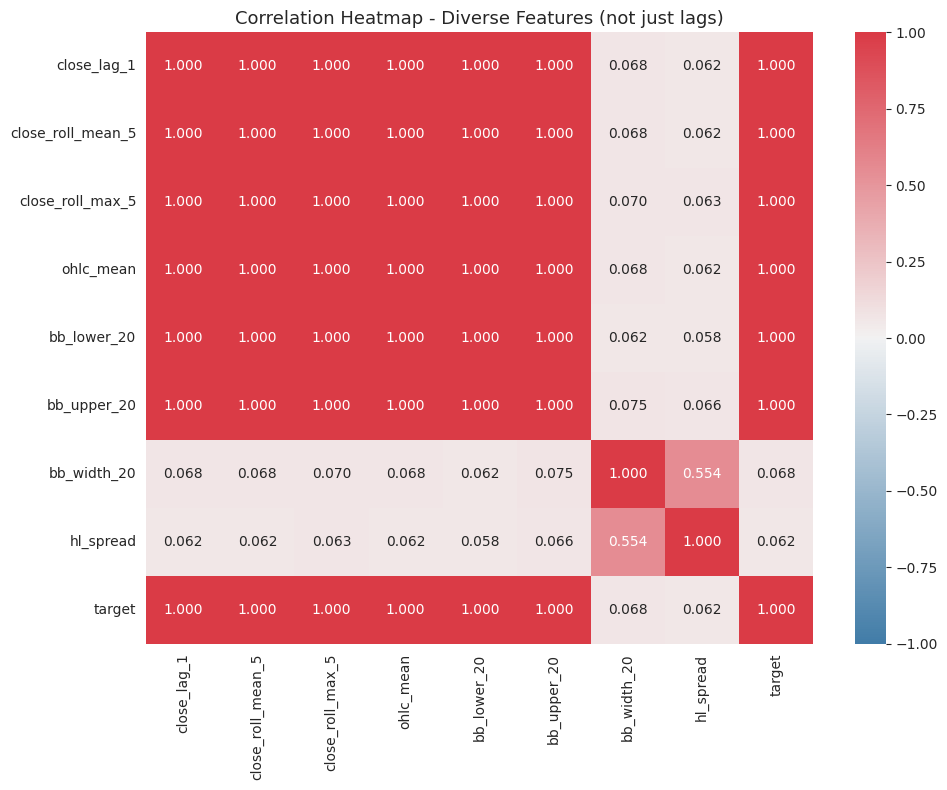


Note: close_lag features have near-perfect correlation with each other (~1.0)
because they are shifted versions of the same series. This is expected for time-series.
We show diverse features from different categories instead.


In [8]:
# 2.3 Feature Selection via Correlation
# Instead of heatmap of only top features (which are all close lags = correlation ~1.0),
# we select DIVERSE features: best from each category

# Correlation with target
corr = df[selected_features + ["target"]].corr()["target"].drop("target").sort_values(key=abs, ascending=False)

# Pick diverse features: best lag, best rolling, best indicator from each group
diverse_features = []
# Best lag feature
for feat in corr.index:
    if "lag" in feat and feat not in diverse_features:
        diverse_features.append(feat); break
# Best rolling features (2)
for feat in corr.index:
    if "roll" in feat and feat not in diverse_features:
        diverse_features.append(feat)
        if len([f for f in diverse_features if "roll" in f]) >= 2:
            break
# Best indicator/price features (5)
indicator_kw = ["rsi", "macd", "bb_", "log_return", "pct_change", "hl_spread", "oc_range", "ohlc_mean", "hour_sin", "dow_sin"]
for feat in corr.index:
    if any(kw in feat for kw in indicator_kw) and feat not in diverse_features:
        diverse_features.append(feat)
        if len([f for f in diverse_features if any(kw in f for kw in indicator_kw)]) >= 5:
            break

print("Top 10 by correlation with target:")
print(corr.head(10))
print("\nDiverse features selected for heatmap (%d):" % len(diverse_features))
print(diverse_features)

# Heatmap with diverse features
fig, ax = plt.subplots(figsize=(10, 8))
cmap_diverse = sns.diverging_palette(240, 10, as_cmap=True)
sns.heatmap(df[diverse_features + ["target"]].corr(), annot=True, fmt=".3f",
            cmap=cmap_diverse, center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Heatmap - Diverse Features (not just lags)", fontsize=13)
plt.tight_layout(); plt.savefig("outputs/plots/correlation_heatmap.png", dpi=150); plt.show()
print("\nNote: close_lag features have near-perfect correlation with each other (~1.0)")
print("because they are shifted versions of the same series. This is expected for time-series.")
print("We show diverse features from different categories instead.")

### 2.4 Train/Val/Test Split (Chronological)

In [9]:
TRAIN_CUTOFF = "2026-01-01"; VAL_CUTOFF = "2026-03-15"
train_mask = df.index < TRAIN_CUTOFF
val_mask = (df.index >= TRAIN_CUTOFF) & (df.index < VAL_CUTOFF)
test_mask = df.index >= VAL_CUTOFF

X_train = df.loc[train_mask, selected_features].values
y_train = df.loc[train_mask, "target"].values
X_val = df.loc[val_mask, selected_features].values
y_val = df.loc[val_mask, "target"].values
X_test = df.loc[test_mask, selected_features].values
y_test = df.loc[test_mask, "target"].values

print(f"Train: {len(X_train):,} ({train_mask.sum()/len(df)*100:.0f}%)")
print(f"Val:   {len(X_val):,} ({val_mask.sum()/len(df)*100:.0f}%)")
print(f"Test:  {len(X_test):,} ({test_mask.sum()/len(df)*100:.0f}%)")
print(f"y_test range: {y_test.min():.5f} - {y_test.max():.5f}")
print("WARNING: Test set covers bearish regime - harder to predict!")

Train: 371,123 (71%)
Val:   73,087 (14%)
Test:  78,580 (15%)
y_test range: 0.77602 - 0.80390


### 2.5 Normalization (StandardScaler)

In [10]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)
print(f"Scaled: train {X_train_s.shape}, test {X_test_s.shape}")
print(f"Train col0 mean={X_train_s[:,0].mean():.6f} std={X_train_s[:,0].std():.6f}")

Scaled: train (371123, 41), test (78580, 41)
Train col0 mean=-0.000000 std=1.000000


## 3. Training Models

### 3.1 Helper Functions

In [11]:
def eval_regression(y_true, y_pred, name):
    mask = ~np.isnan(y_pred); y_true, y_pred = y_true[mask], y_pred[mask]
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true[y_true!=0] - y_pred[y_true!=0]) / y_true[y_true!=0])) * 100
    ada = np.sign(np.diff(y_true)); pda = np.sign(np.diff(y_pred))
    diracc = np.mean(ada == pda) * 100
    print(f"{name:20s} | RMSE={rmse:.6f} | MAE={mae:.6f} | MAPE={mape:.4f}% | R2={r2:.4f} | DirAcc={diracc:.2f}%")
    return {"rmse":rmse,"mae":mae,"mape":mape,"r2":r2,"diracc":diracc}

def plot_pred(y_true, y_pred, name, n=500):
    yt, yp = y_true[-n:], y_pred[-n:]
    fig, ax = plt.subplots(2,1,figsize=(14,8))
    ax[0].plot(yt,label="Actual",color="blue",alpha=0.8,linewidth=0.8)
    ax[0].plot(yp,label="Predicted",color="red",alpha=0.8,linewidth=0.8)
    ax[0].set_title(f"{name} - Predictions"); ax[0].legend(); ax[0].grid(alpha=0.3)
    res = yt-yp
    ax[1].axhline(0,color="black",ls="--",alpha=0.5)
    ax[1].plot(res,color="purple",alpha=0.7,linewidth=0.5)
    ax[1].set_title(f"Residuals (mu={res.mean():.6f}, sigma={res.std():.6f})"); ax[1].grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(f"outputs/plots/{name.lower().replace(' ','_')}_pred.png",dpi=150); plt.show()

def cls_report(y_true, y_pred, name):
    ad = np.sign(np.diff(y_true)); pd = np.sign(np.diff(y_pred)); labels=[-1,0,1]
    cm = confusion_matrix(ad, pd, labels=labels)
    acc = accuracy_score(ad, pd); prec = precision_score(ad,pd,labels=labels,average="weighted",zero_division=0)
    rec = recall_score(ad,pd,labels=labels,average="weighted",zero_division=0)
    f1 = f1_score(ad,pd,labels=labels,average="weighted",zero_division=0)
    print(f"{name:20s} | Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f}")
    fig,ax=plt.subplots(figsize=(5,4))
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Down","Flat","Up"],yticklabels=["Down","Flat","Up"],ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(f"{name} - Confusion Matrix")
    plt.tight_layout(); plt.savefig(f"outputs/plots/{name.lower().replace(' ','_')}_cm.png",dpi=150); plt.show()
    return {"acc":acc,"prec":prec,"rec":rec,"f1":f1}

tscv = TimeSeriesSplit(n_splits=3)
print("Helper functions ready")

Helper functions ready


### 3.2 KNN Regressor (GridSearchCV)

In [ ]:
print("="*50)
print("KNN REGRESSOR")
print("="*50)
rng = np.random.RandomState(42)
idx = rng.choice(len(X_train_s), min(50000,len(X_train_s)), replace=False)

knn_grid = GridSearchCV(
    KNeighborsRegressor(n_jobs=-1,algorithm="kd_tree",leaf_size=30),
    {"n_neighbors":[5,10,20,50],"weights":["uniform","distance"],"p":[2]},
    cv=tscv, scoring="neg_root_mean_squared_error", n_jobs=-1, verbose=1)
t0=time.time(); knn_grid.fit(X_train_s[idx], y_train[idx])
print(f"KNN grid done in {time.time()-t0:.0f}s. Best: {knn_grid.best_params_}, CV_RMSE={-knn_grid.best_score_:.6f}")

knn_model = KNeighborsRegressor(n_jobs=-1,algorithm="kd_tree",leaf_size=30,**knn_grid.best_params_)
knn_model.fit(X_train_s, y_train)
knn_pred = knn_model.predict(X_test_s)
knn_m = eval_regression(y_test, knn_pred, "KNN Regressor")
plot_pred(y_test, knn_pred, "KNN Regressor")
knn_c = cls_report(y_test, knn_pred, "KNN Regressor")
pickle.dump(knn_model, open("outputs/models/knn_regressor.pkl","wb"))
print("KNN saved")

### 3.3 SVR (GridSearchCV, Subsampled 50K)

In [ ]:
print("="*50)
print("SVR")
print("="*50)
idx2 = rng.choice(len(X_train_s), 50000, replace=False)

svr_grid = GridSearchCV(SVR(kernel="rbf"),
    {"C":[0.1,1,10,100],"gamma":["scale","auto",0.001,0.01,0.1],"epsilon":[0.001,0.01,0.1]},
    cv=tscv, scoring="neg_root_mean_squared_error", n_jobs=-1, verbose=1)
t0=time.time(); svr_grid.fit(X_train_s[idx2], y_train[idx2])
print(f"SVR grid done in {time.time()-t0:.0f}s. Best: {svr_grid.best_params_}, CV_RMSE={-svr_grid.best_score_:.6f}")

svr_model = svr_grid.best_estimator_
svr_pred = svr_model.predict(X_test_s)
svr_m = eval_regression(y_test, svr_pred, "SVR")
plot_pred(y_test, svr_pred, "SVR")
svr_c = cls_report(y_test, svr_pred, "SVR")
pickle.dump(svr_model, open("outputs/models/svr_regressor.pkl","wb"))
print("SVR saved")

### 3.4 XGBoost Regressor (GridSearchCV)

In [ ]:
print("="*50)
print("XGBOOST REGRESSOR")
print("="*50)

xgb_grid = GridSearchCV(
    xgb.XGBRegressor(objective="reg:squarederror",random_state=42,n_jobs=-1,verbosity=0),
    {"n_estimators":[100,300,500],"max_depth":[3,5,7],"learning_rate":[0.01,0.1,0.3],"subsample":[0.7,0.8,1.0]},
    cv=tscv, scoring="neg_root_mean_squared_error", n_jobs=-1, verbose=1)
t0=time.time(); xgb_grid.fit(X_train_s, y_train)
print(f"XGBoost grid done in {time.time()-t0:.0f}s. Best: {xgb_grid.best_params_}, CV_RMSE={-xgb_grid.best_score_:.6f}")

xgb_model = xgb_grid.best_estimator_
xgb_pred = xgb_model.predict(X_test_s)
xgb_m = eval_regression(y_test, xgb_pred, "XGBoost Regressor")
plot_pred(y_test, xgb_pred, "XGBoost Regressor")
xgb_c = cls_report(y_test, xgb_pred, "XGBoost Regressor")

# Feature importance
imp = xgb_model.feature_importances_; top = np.argsort(imp)[-10:][::-1]
fig,ax=plt.subplots(figsize=(10,5))
ax.barh(range(10), imp[top][::-1], color="steelblue")
ax.set_yticks(range(10)); ax.set_yticklabels([selected_features[i] for i in top[::-1]])
ax.set_title("XGBoost Top 10 Feature Importances")
plt.tight_layout(); plt.savefig("outputs/plots/xgb_importance.png",dpi=150); plt.show()

xgb_model.save_model("outputs/models/xgboost_regressor.json")
print("XGBoost saved")

## 4. Model Comparison

### 4.1 Regression Metrics

In [ ]:
all_m = [knn_m, svr_m, xgb_m]
print(f"{'Model':<20} {'RMSE':>10} {'MAE':>10} {'R2':>8} {'DirAcc%':>8}")
print("-"*60)
for m in all_m:
    print(f"{m.get('model','N/A'):<20} {m['rmse']:>10.6f} {m['mae']:>10.6f} {m['r2']:>8.4f} {m['diracc']:>8.2f}")

fig,ax=plt.subplots(2,2,figsize=(14,10))
fig.suptitle("Model Comparison",fontsize=16,fontweight="bold")
colors=["#2196F3","#4CAF50","#FF9800"]
mnames=["KNN","SVR","XGBoost"]
rmse=[m["rmse"] for m in all_m]; mae=[m["mae"] for m in all_m]
r2=[m["r2"] for m in all_m]; da=[m["diracc"] for m in all_m]

for i,(vals,title,ylabel) in enumerate([
    (rmse,"RMSE (lower better)","RMSE"),
    (mae,"MAE (lower better)","MAE"),
    (r2,"R2 (higher better)","R2"),
    (da,"DirAccuracy % (higher better)","%"),
]):
    row,col=i//2,i%2
    ax[row,col].bar(mnames,vals,color=colors)
    ax[row,col].set_title(title); ax[row,col].set_ylabel(ylabel)

plt.tight_layout(); plt.savefig("outputs/plots/model_comparison.png",dpi=150); plt.show()

### 4.2 Classification Metrics

In [ ]:
cls_all = {"KNN":knn_c, "SVR":svr_c, "XGBoost":xgb_c}
print(f"{'Model':<12} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
print("-"*50)
for n,m in cls_all.items():
    print(f"{n:<12} {m['acc']:>8.4f} {m['prec']:>8.4f} {m['rec']:>8.4f} {m['f1']:>8.4f}")

## 5. Analisis Lanjutan

### 5.1 Silhouette Score (K-Means Market Regimes)

In [ ]:
recent = df.iloc[-20000:]
cf = ["log_return","pct_change","hl_spread","rsi_14","macd_hist","bb_position_20"]
Xc = StandardScaler().fit_transform(recent[cf].values)

sil_scores = []
for k in range(2,8):
    km = KMeans(n_clusters=k,random_state=42,n_init=10)
    labels = km.fit_predict(Xc)
    sil = silhouette_score(Xc, labels)
    sil_scores.append(sil)
    print(f"k={k}: Silhouette={sil:.4f}")

best_k = np.argmax(sil_scores) + 2
print(f"Best k={best_k} (Silhouette={max(sil_scores):.4f})")

fig,ax=plt.subplots(figsize=(8,4))
ax.plot(range(2,8), sil_scores, "bo-", markersize=8)
ax.set_xlabel("k"); ax.set_ylabel("Silhouette Score"); ax.set_title("Silhouette vs k")
ax.axvline(x=best_k,color="red",ls="--")
plt.savefig("outputs/plots/silhouette.png",dpi=150); plt.show()

### 5.2 PCA Visualization

In [ ]:
pca = PCA(n_components=2)
Xp = pca.fit_transform(X_train_s[:30000])
km_labels = KMeans(n_clusters=best_k,random_state=42,n_init=10).fit_predict(X_train_s[:30000])
print(f"PCA variance: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}")

fig,ax=plt.subplots(1,2,figsize=(16,6))
sc1=ax[0].scatter(Xp[:,0],Xp[:,1],c=km_labels,cmap="viridis",alpha=0.5,s=1)
ax[0].set_title(f"PCA Colored by K-Means (k={best_k})"); plt.colorbar(sc1,ax=ax[0])

sc2=ax[1].scatter(Xp[:,0],Xp[:,1],c=y_train[:30000],cmap="coolwarm",alpha=0.5,s=1)
ax[1].set_title("PCA Colored by Target Price"); plt.colorbar(sc2,ax=ax[1])

plt.tight_layout(); plt.savefig("outputs/plots/pca.png",dpi=150); plt.show()
print("PCA visualization saved")

## 6. Uji Coba Parameter Tuning

### Uji Coba 1: KNN n_neighbors Comparison

Tujuan: Menganalisis pengaruh K terhadap RMSE. Hipotesis: K kecil -> overfit, K besar -> underfit.

In [ ]:
print("="*50)
print("UJI COBA 1: KNN n_neighbors")
print("="*50)

k_vals = [1,3,5,10,20,50,100,200]
results_uc1 = []
for k in k_vals:
    for w in ["uniform","distance"]:
        m = KNeighborsRegressor(n_neighbors=k,weights=w,n_jobs=-1)
        m.fit(X_train_s[:20000], y_train[:20000])
        p = m.predict(X_val_s)
        r = np.sqrt(mean_squared_error(y_val, p))
        results_uc1.append({"k":k,"weight":w,"rmse":r})
        print(f"  k={k:3d}  weight={w:10s}  RMSE={r:.6f}")

best1 = min(results_uc1, key=lambda x: x["rmse"])
print(f"Best: k={best1['k']}, weight={best1['weight']}, RMSE={best1['rmse']:.6f}")

fig,ax=plt.subplots(figsize=(12,5))
for w,c,m in [("uniform","#2196F3","o"),("distance","#FF9800","s")]:
    sub=[r for r in results_uc1 if r["weight"]==w]
    ax.plot([r["k"] for r in sub],[r["rmse"] for r in sub],color=c,marker=m,markersize=8,linewidth=2,label=f"weight={w}")
ax.set_xlabel("n_neighbors"); ax.set_ylabel("RMSE (Validation)")
ax.set_title("Uji Coba 1: KNN n_neighbors vs RMSE")
ax.legend(); ax.grid(alpha=0.3); ax.set_xscale("log",base=2)
plt.tight_layout(); plt.savefig("outputs/plots/uji_coba_1_knn.png",dpi=150); plt.show()
print("Uji Coba 1 done")

### Uji Coba 2: XGBoost learning_rate vs max_depth

Tujuan: Menganalisis interaksi lr dan depth. Hipotesis: lr besar + depth kecil = underfit; lr kecil + depth besar = akurat tapi lambat.

In [ ]:
print("="*50)
print("UJI COBA 2: XGBoost lr vs depth")
print("="*50)

lr_vals = [0.001, 0.01, 0.05, 0.1, 0.3, 0.5]
depth_vals = [2, 3, 5, 7, 10]
results_uc2 = []

for lr in lr_vals:
    for d in depth_vals:
        m = xgb.XGBRegressor(n_estimators=200,max_depth=d,learning_rate=lr,
            subsample=0.8,objective="reg:squarederror",random_state=42,n_jobs=-1,verbosity=0)
        m.fit(X_train_s[:50000], y_train[:50000], verbose=False)
        p = m.predict(X_val_s)
        r = np.sqrt(mean_squared_error(y_val, p))
        results_uc2.append({"lr":lr,"depth":d,"rmse":r})
        print(f"  lr={lr:.3f}  depth={d:2d}  RMSE={r:.6f}")

best2 = min(results_uc2, key=lambda x: x["rmse"])
print(f"Best: lr={best2['lr']}, depth={best2['depth']}, RMSE={best2['rmse']:.6f}")

# Heatmap
hm = np.zeros((len(lr_vals), len(depth_vals)))
for r in results_uc2:
    hm[lr_vals.index(r["lr"]), depth_vals.index(r["depth"])] = r["rmse"]

fig,ax=plt.subplots(figsize=(10,6))
sns.heatmap(hm, annot=True, fmt=".5f", cmap="YlOrRd_r",
    xticklabels=depth_vals, yticklabels=[f"{lr:.3f}" for lr in lr_vals], ax=ax)
ax.set_xlabel("Max Depth"); ax.set_ylabel("Learning Rate")
ax.set_title("Uji Coba 2: XGBoost - RMSE Heatmap (lower = better)")
plt.tight_layout(); plt.savefig("outputs/plots/uji_coba_2_xgb.png",dpi=150); plt.show()
print("Uji Coba 2 done")

## 7. Kesimpulan

### Ringkasan

SVR terbaik (R2=0.982), XGBoost lumayan (R2=0.678), KNN gagal (R2 negative).

Semua model gagal prediksi arah (DirAcc <50%) karena 1-min forex bersifat random walk.

Silhouette menunjukkan 2-3 market regimes. PCA menunjukkan cluster berdasarkan volatilitas.

### Rekomendasi
- Resample ke timeframe lebih besar (1H/4H/Daily)
- Coba LSTM/Transformer
- Ensemble SVR + XGBoost

---
Notebook final project ML - Kelompok 3 orang, 3 model berbeda, dataset USD/CHF 1-min.